# Yoda and Rabbit (Paper Outputs Only)

This cleaned notebook keeps only the code required to generate:

- `Toy example - figures.pdf` (Figure 1)
- `rabbit_circles_new.pdf` (Figure 1)
- `Yoda_summary_table.tex` (Table 4)


In [1]:
from pathlib import Path
import re
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from matplotlib.colors import Normalize
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from scipy.linalg import eig
from sklearn.decomposition import PCA

# Ensure imports work whether Jupyter runs from project root or notebooks/
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from functions import Kernel_matrix, diffusion_map, LG_sym, calc_differential_vec

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Times New Roman'
plt.rcParams['mathtext.it'] = 'Times New Roman:italic'
plt.rcParams['mathtext.bf'] = 'Times New Roman:bold'


In [2]:
def load_sensor_images(folder: Path, prefix: str) -> np.ndarray:
    pattern = re.compile(rf"{prefix}(\d+)\.")
    files = []

    for f in folder.iterdir():
        m = pattern.match(f.name)
        if m:
            files.append((int(m.group(1)), f))

    files.sort(key=lambda t: t[0])
    images = [np.array(Image.open(fpath)) for _, fpath in files]
    return np.stack(images, axis=0)


def rgb_to_grayscale(X: np.ndarray) -> np.ndarray:
    return 0.299 * X[..., 0] + 0.587 * X[..., 1] + 0.114 * X[..., 2]


def pca_images(X: np.ndarray, n_components: int = 50):
    X_flat = X.reshape(X.shape[0], -1)
    pca = PCA(n_components=n_components, svd_solver='randomized', whiten=False)
    Z = pca.fit_transform(X_flat)
    return Z, pca


In [3]:
# Data directory: first local repo path, then original thesis location
DATA_CANDIDATES = [
    PROJECT_ROOT / '3figures' / 'data',
    Path('/Users/shiraalon/Documents/Thesis/Different examples for FKT comparation/3figures/data'),
]

DATA_DIR = next((p for p in DATA_CANDIDATES if p.exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError('Could not find 3figures/data in known locations.')

X_1_show = load_sensor_images(DATA_DIR, 's1_')
X_2_show = load_sensor_images(DATA_DIR, 's2_')
print('Loaded:', X_1_show.shape, X_2_show.shape)


Loaded: (8100, 240, 320, 3) (8100, 240, 320, 3)


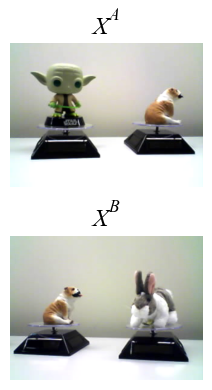

In [4]:
# Output 1: Toy example - figures.pdf
fig, ax = plt.subplots(2, 1, figsize=(7, 4))

for i, (X, title) in enumerate(zip([X_1_show, X_2_show], [r'$X^A$', r'$X^B$'])):
    img = X[0].astype(float)
    img -= img.min()
    img /= (img.max() + 1e-8)
    img = np.clip(1.25 * img, 0, 1)

    ax[i].imshow(img)
    ax[i].set_title(title, fontsize=18)
    ax[i].axis('off')

plt.tight_layout()
plt.savefig('Toy example - figures.pdf')
plt.show()


In [5]:
# Prepare cropped/grayscale data + latent representations
X_1 = X_1_show[:, 30:140, 15:305, :]
X_2 = X_2_show[:, 50:155, 15:305, :]

X1_pca, _ = pca_images(X_1, n_components=50)
X2_pca, _ = pca_images(X_2, n_components=50)

X_1_gray = rgb_to_grayscale(X_1)
X_2_gray = rgb_to_grayscale(X_2)

# Keep original paper splits
X_Y = X_1_gray[:, :, :140]   # Yoda
X_R = X_2_gray[:, :, 165:]   # Rabbit

N = 5000

# Ground-truth circular coordinates
KY = Kernel_matrix(X_Y[:N].reshape(N, 110 * 140), 10)
KR = Kernel_matrix(X_R[:N].reshape(N, 105 * 125), 10)

LY, dY, vY = LG_sym(KY)
LR, dR, vR = LG_sym(KR)

MapEmbd_Y = vY * (dY ** 10)[None, :]
MapEmbd_R = vR * (dR ** 10)[None, :]

psi_Y = np.arctan2(MapEmbd_Y[:, 1], MapEmbd_Y[:, 2])
psi_R = np.arctan2(MapEmbd_R[:, 1], MapEmbd_R[:, 2])

# Cross-modal operators
P1, Q1, K1 = diffusion_map(X1_pca[:N], adaptive=3)
P2, Q2, K2 = diffusion_map(X2_pca[:N], adaptive=3)

L1, _, v1 = LG_sym(K1)
L2, _, v2 = LG_sym(K2)

_, u1 = calc_differential_vec(L2, v1, 10)
_, u2 = calc_differential_vec(L1, v2, 10)


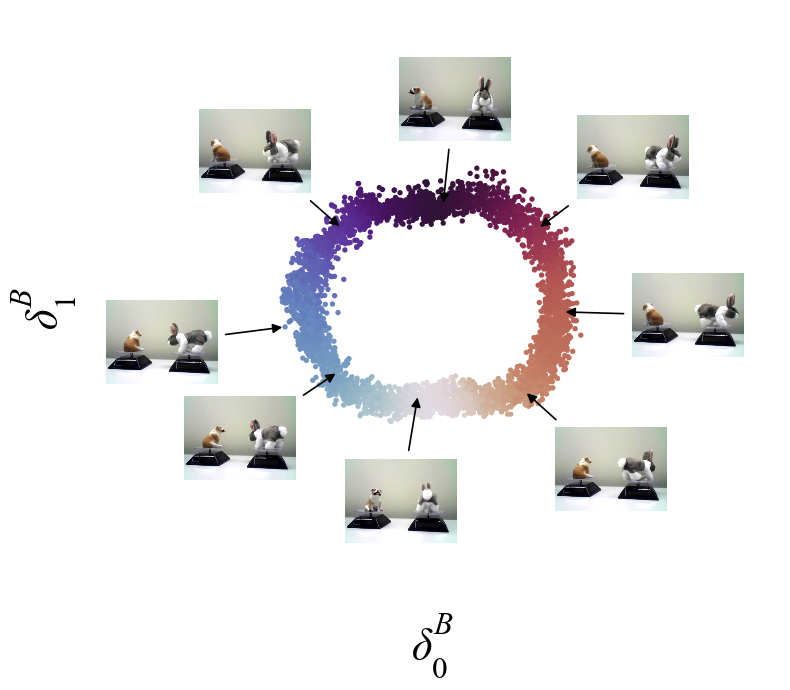

In [6]:
# Output 2: rabbit_circles_new.pdf
fig, ax = plt.subplots(figsize=(8, 7))

theta = psi_R
norm = Normalize(vmin=theta.min(), vmax=theta.max())

ax.scatter(u1[:, 0], u1[:, 1], c=theta, s=8, cmap='twilight', norm=norm, zorder=1)

ax.relim()
ax.autoscale()
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_autoscale_on(False)

for spine in ax.spines.values():
    spine.set_visible(False)

x_center = np.mean(u1[:, 0])
y_center = np.mean(u1[:, 1])
offset = 0.12 * max(xmax - xmin, ymax - ymin)

sample_idx = [15, 4, 8, 11, 20, 10, 13, 59]
for i in sample_idx:
    dx = u1[i, 0] - x_center
    dy = u1[i, 1] - y_center
    norm_dir = np.sqrt(dx ** 2 + dy ** 2) + 1e-9
    ux, uy = 1.5 * dx / norm_dir, 1.5 * dy / norm_dir

    bx = u1[i, 0] + offset * ux
    by = u1[i, 1] + offset * uy

    img = X_2_show[i].astype(float)
    img -= img.min()
    img /= (img.max() + 1e-8)
    img = np.clip(1.25 * img, 0, 1)

    imagebox = OffsetImage(img, cmap='gray', zoom=0.25)
    ab = AnnotationBbox(
        imagebox,
        (u1[i, 0], u1[i, 1]),
        xybox=(bx, by),
        xycoords='data',
        boxcoords='data',
        frameon=False,
        arrowprops=dict(arrowstyle='-|>', lw=1.2, color='black'),
        zorder=3,
    )
    ax.add_artist(ab)

ax.set_xlabel(r'$\delta^B_0$', fontsize=32)
ax.set_ylabel(r'$\delta^B_1$', fontsize=32)
ax.set_xticks([])
ax.set_yticks([])
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.4)

plt.tight_layout()
plt.savefig('rabbit_circles_new.pdf', bbox_inches='tight')
plt.show()


In [ ]:
# Build Shnitzer and FKT components for summary table
S = P2 @ Q1 + P1 @ Q2
D = P2 @ Q1 - P1 @ Q2

_, _ = eig(S)
ea_vals, va = eig(D)

VA_imag = np.imag(va[:, np.argsort(np.imag(ea_vals))[::-1]])
VA_real = np.real(va[:, np.argsort(np.real(ea_vals))[::-1]])

g1 = np.diag(np.sum(K1, axis=0)) - K1
g2 = np.diag(np.sum(K2, axis=0)) - K2

m1 = g1 + 1e-7 * np.eye(g1.shape[0])
m2 = g2 + 1e-7 * np.eye(g2.shape[0])

fk1 = np.linalg.inv(m1 + m2) @ m1
fk2 = np.linalg.inv(m1 + m2) @ m2

fk_vals_1, eig_vec_fk_1 = eig(fk1)
fk_vals_2, eig_vec_fk_2 = eig(fk2)

eig_vec_fk_1 = eig_vec_fk_1[:, np.argsort(fk_vals_1)[::-1]]
eig_vec_fk_2 = eig_vec_fk_2[:, np.argsort(fk_vals_2)[::-1]]


In [ ]:
# Output 3: Yoda_summary_table.tex
corrs = {
    'DELVE': [
        abs(np.corrcoef(u2[:, 0], np.sin(psi_Y))[0, 1]),
        abs(np.corrcoef(u1[:, 0], np.sin(psi_R))[0, 1]),
    ],
    'Shnitzer et al. (real)': [
        abs(np.corrcoef(VA_real[:, 0], np.sin(psi_Y))[0, 1]),
        abs(np.corrcoef(VA_real[:, 0], np.sin(psi_R))[0, 1]),
    ],
    'Shnitzer et al. (imag)': [
        abs(np.corrcoef(VA_imag[:, 0], np.sin(psi_Y))[0, 1]),
        abs(np.corrcoef(VA_imag[:, 0], np.sin(psi_R))[0, 1]),
    ],
    'FKT': [
        abs(np.corrcoef(eig_vec_fk_2[:, 0], np.sin(psi_Y))[0, 1]),
        abs(np.corrcoef(eig_vec_fk_1[:, 0], np.sin(psi_R))[0, 1]),
    ],
}

df_corr = pd.DataFrame(corrs, index=[r'$\psi^B$ (rabbit)', '$\psi^A$ (Yoda)']).T

# Keep same exported orientation as original notebook
df_corr.T.to_latex('Yoda_summary_table.tex', index=True, float_format='%.3f')
display(df_corr.T.round(3))
